In [16]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ---------------------------
# 1️⃣ Load and prepare dataset
# ---------------------------
df = pd.read_excel(
    'D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx'
)
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Handle gaps
df['energy_increment_fixed'] = df['energy_increment_kwh'].copy()
df.loc[df['gap_flag'] == 1, 'energy_increment_fixed'] = 0

# ---------------------------
# 2️⃣ Compute 5-min target
# ---------------------------
horizon = 5
df['target_future_sum'] = df['energy_increment_fixed'].rolling(window=horizon).sum().shift(-horizon)
df = df.dropna(subset=['target_future_sum'])

# ---------------------------
# 3️⃣ Add 5-min aligned lag features
# ---------------------------
lag_cols = ['power','current','voltage','energy_increment_fixed','apparent_power','power_factor']
for col in lag_cols:
    df[f'{col}_lag1_5min'] = df[col].shift(horizon)
    df[f'{col}_lag2_5min'] = df[col].shift(horizon*2)

# Drop rows with NaN after lag creation
df = df.dropna().reset_index(drop=True)
df['power_current'] = df['power'] * df['current']
# ---------------------------
# 4️⃣ Select features
# ---------------------------
selected_features = [
    'power','voltage','power_factor','power_current',
    'power_lag5','power_lag10',
    'energy_increment_kwh_lag1','energy_increment_kwh_lag2','energy_increment_kwh_lag3',
    'energy_increment_kwh_lag5','energy_increment_kwh_lag10',
    'power_rolling_std_3','power_rolling_std_5',
    'power_rolling_std_10',
    'energy_increment_kwh_rolling_mean_3','energy_increment_kwh_rolling_std_3',
    'energy_increment_kwh_rolling_mean_5','energy_increment_kwh_rolling_std_5',
    'energy_increment_kwh_rolling_mean_10','energy_increment_kwh_rolling_std_10',
    'hour_sin','hour_cos','day_of_week_sin','day_of_week_cos','is_weekend',
    'time_diff_min','gap_flag','delta_power','delta_voltage','delta_energy',
   
]

X = df[selected_features].fillna(0)
y = df['target_future_sum']

# ---------------------------
# 5️⃣ Create interaction & polynomial features
# ---------------------------
# Interaction terms


# ---------------------------
# 6️⃣ Train/test split (time-based)
# ---------------------------
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ---------------------------
# 7️⃣ Scale numeric features
# ---------------------------
numeric_cols = X.select_dtypes(include=['float64','int64']).columns
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# ---------------------------
# 8️⃣ Drop highly correlated features before training
# ---------------------------
threshold = 0.9
corr_matrix = X_train_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns to drop
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
print("Dropping highly correlated features:")
print(to_drop)

# Drop from train and test
X_train_reduced = X_train_scaled.drop(columns=to_drop)
X_test_reduced = X_test_scaled.drop(columns=to_drop)

# ---------------------------
# 9️⃣ Train Linear Regression on reduced features
# ---------------------------
lr_model = LinearRegression()
lr_model.fit(X_train_reduced, y_train)
y_pred_lr = lr_model.predict(X_test_reduced)

# ---------------------------
# 10️⃣ Evaluation
# ---------------------------
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Linear Regression (Reduced Correlation) ===")
print(f"MAE:{mae_lr:.6f}, RMSE:{rmse_lr:.6f}, R²:{r2_lr:.6f}")


Dropping highly correlated features:
[]
=== Linear Regression (Reduced Correlation) ===
MAE:0.000697, RMSE:0.001357, R²:0.815791


In [43]:
# from sklearn.linear_model import Ridge


from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import Ridge

tscv = TimeSeriesSplit(n_splits=5)

ridge_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train_reduced, y_train)
best_ridge = ridge_grid.best_estimator_

y_pred_ridge = best_ridge.predict(X_test_reduced)

print("Best alpha (TS):", ridge_grid.best_params_)
print("=== Ridge (TimeSeriesSplit) ===")
print(f"MAE:{mean_absolute_error(y_test, y_pred_ridge):.6f}")
print(f"RMSE:{np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.6f}")
print(f"R²:{r2_score(y_test, y_pred_ridge):.6f}")



Best alpha: {'alpha': 100}
=== Improved Ridge Regression ===
MAE:0.000750, RMSE:0.001461, R²:0.786600


In [41]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_reduced, y_train)
y_pred_lasso = lasso.predict(X_test_reduced)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("=== Lasso Regression ===")
print(f"MAE:{mae_lasso:.6f}, RMSE:{rmse_lasso:.6f}, R²:{r2_lasso:.6f}")



=== Lasso Regression ===
MAE:0.000696, RMSE:0.001383, R²:0.808797


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000726 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6066
[LightGBM] [Info] Number of data points in the train set: 4046, number of used features: 38
[LightGBM] [Info] Start training from score 0.003867
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

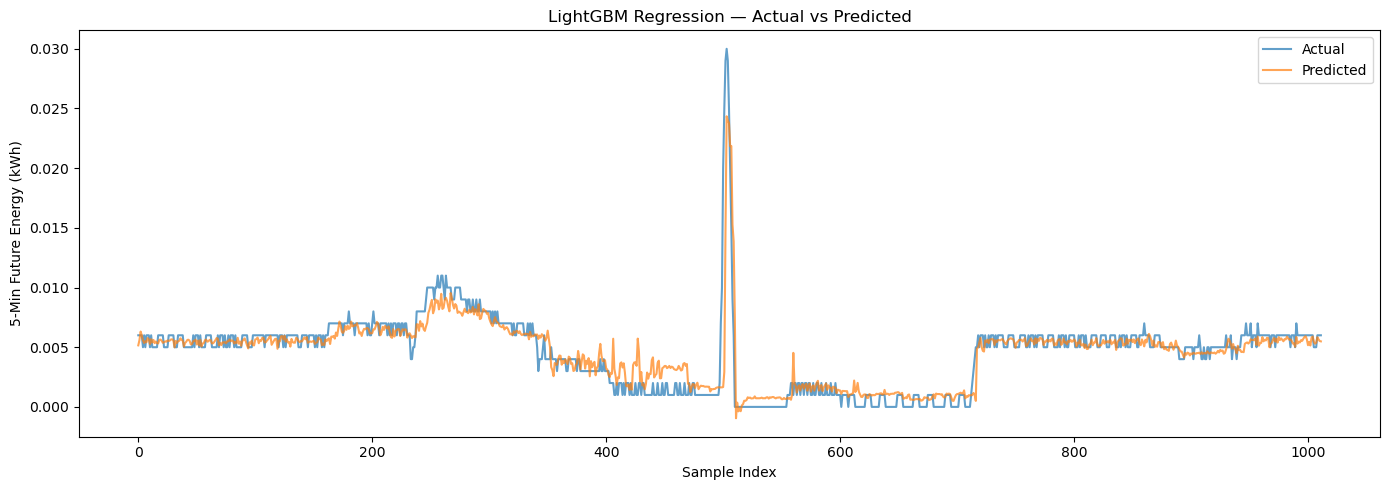

In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import matplotlib.pyplot as plt

# ============================================================
# 1️⃣ Load and preprocess dataset
# ============================================================
df = pd.read_excel(
    'D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx'
)
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Handle missing increments
df['energy_increment_fixed'] = df['energy_increment_kwh'].copy()
df.loc[df['gap_flag'] == 1, 'energy_increment_fixed'] = 0

# Fill NaNs for lag/rolling features
lag_rolling_cols = [c for c in df.columns if 'lag' in c or 'rolling' in c]
df[lag_rolling_cols] = df[lag_rolling_cols].fillna(0)

# ============================================================
# 2️⃣ Define target (5-min future energy)
# ============================================================
horizon = 5
df['target_future_sum'] = (
    df['energy_increment_fixed']
    .rolling(window=horizon)
    .sum()
    .shift(-horizon)
)

df = df.dropna(subset=['target_future_sum']).reset_index(drop=True)

# ============================================================
# 3️⃣ Select features
# ============================================================
selected_features = [
    'power','current','voltage','power_factor','apparent_power','pf_efficiency',
    'power_lag1','power_lag2','power_lag3','power_lag5','power_lag10',
    'energy_increment_kwh_lag1','energy_increment_kwh_lag2','energy_increment_kwh_lag3',
    'energy_increment_kwh_lag5','energy_increment_kwh_lag10',
    'power_rolling_mean_3','power_rolling_std_3',
    'power_rolling_mean_5','power_rolling_std_5',
    'power_rolling_mean_10','power_rolling_std_10',
    'energy_increment_kwh_rolling_mean_3','energy_increment_kwh_rolling_std_3',
    'energy_increment_kwh_rolling_mean_5','energy_increment_kwh_rolling_std_5',
    'energy_increment_kwh_rolling_mean_10','energy_increment_kwh_rolling_std_10',
    'hour_sin','hour_cos','day_of_week_sin','day_of_week_cos','is_weekend',
    'time_diff_min','gap_flag','delta_power','delta_voltage','delta_energy'
]

X = df[selected_features].fillna(0)
y = df['target_future_sum']

# ============================================================
# 4️⃣ Time-based split
# ============================================================
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ============================================================
# 5️⃣ Scale features
# ============================================================
numeric_cols = X.select_dtypes(include=['float64','int64']).columns
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# ============================================================
# 6️⃣ Train LightGBM Regressor
# ============================================================
lgb_model = lgb.LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(50)
    ]
)

# ============================================================
# 7️⃣ Evaluate LightGBM
# ============================================================
y_pred = lgb_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n=== LightGBM Regression Results ===")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

# ============================================================
# 8️⃣ Plot Actual vs Predicted
# ============================================================
plt.figure(figsize=(14,5))
plt.plot(y_test.values, label="Actual", alpha=0.7)
plt.plot(y_pred, label="Predicted", alpha=0.7)
plt.title("LightGBM Regression — Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("5-Min Future Energy (kWh)")
plt.legend()
plt.tight_layout()
plt.show()



=== FINAL XGBoost Regression Results ===
MAE  : 0.000809
RMSE : 0.001683
R²   : 0.722088


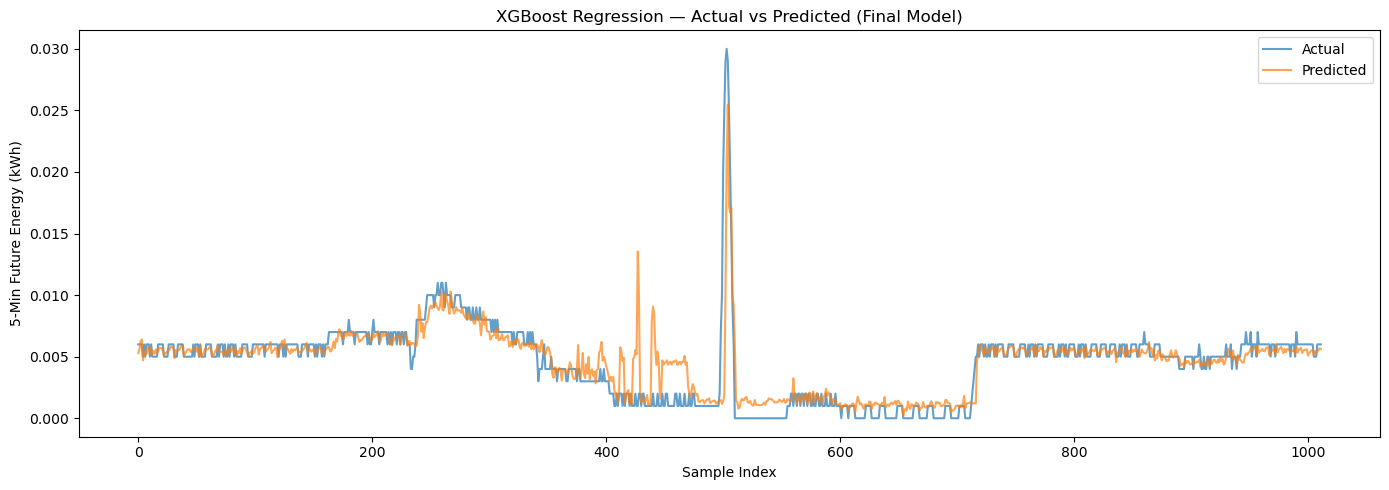

In [50]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ============================================================
# 1️⃣ Load Dataset
# ============================================================
df = pd.read_excel(
    'D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx'
)
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Fix gap issues
df['energy_increment_fixed'] = df['energy_increment_kwh'].copy()
df.loc[df['gap_flag'] == 1, 'energy_increment_fixed'] = 0

# Fill NaNs for lag/rolling columns
lag_rolling_cols = [c for c in df.columns if 'lag' in c or 'rolling' in c]
df[lag_rolling_cols] = df[lag_rolling_cols].fillna(0)

# ============================================================
# 2️⃣ Target Variable (5-min Ahead Forecasting)
# ============================================================
horizon = 5
df['target_future_sum'] = (
    df['energy_increment_fixed']
      .rolling(window=horizon)
      .sum()
      .shift(-horizon)
)
df = df.dropna(subset=['target_future_sum']).reset_index(drop=True)

# ============================================================
# 3️⃣ Final Feature Set (Full Feature Engineering)
# ============================================================
selected_features = [
    # Raw electrical parameters
    'power','current','voltage','power_factor','apparent_power','pf_efficiency',

    # Lag features (full set)
    'power_lag1','power_lag2','power_lag3','power_lag5','power_lag10',
    'energy_increment_kwh_lag1','energy_increment_kwh_lag2','energy_increment_kwh_lag3',
    'energy_increment_kwh_lag5','energy_increment_kwh_lag10',

    # Rolling statistics (full set)
    'power_rolling_mean_3','power_rolling_std_3',
    'power_rolling_mean_5','power_rolling_std_5',
    'power_rolling_mean_10','power_rolling_std_10',
    'energy_increment_kwh_rolling_mean_3','energy_increment_kwh_rolling_std_3',
    'energy_increment_kwh_rolling_mean_5','energy_increment_kwh_rolling_std_5',
    'energy_increment_kwh_rolling_mean_10','energy_increment_kwh_rolling_std_10',

    # Time-based features
    'hour_sin','hour_cos','day_of_week_sin','day_of_week_cos','is_weekend',

    # Additional engineered features
    'time_diff_min','gap_flag','delta_power','delta_voltage','delta_energy'
]

X = df[selected_features].fillna(0)
y = df['target_future_sum']

# ============================================================
# 4️⃣ Time-Based Split
# ============================================================
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ============================================================
# 5️⃣ Train FINAL XGBoost Model (Best Parameters)
# ============================================================
xgb_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# ============================================================
# 6️⃣ Predict & Evaluate
# ============================================================
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n=== FINAL XGBoost Regression Results ===")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

# ============================================================
# 7️⃣ Visualization — Actual vs Predicted
# ============================================================
plt.figure(figsize=(14,5))
plt.plot(y_test.values, label="Actual", alpha=0.7)
plt.plot(y_pred, label="Predicted", alpha=0.7)
plt.title("XGBoost Regression — Actual vs Predicted (Final Model)")
plt.xlabel("Sample Index")
plt.ylabel("5-Min Future Energy (kWh)")
plt.legend()
plt.tight_layout()
plt.show()


Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 0.00179651	valid_0's l2: 3.22746e-06
[100]	valid_0's rmse: 0.00157855	valid_0's l2: 2.49182e-06
[150]	valid_0's rmse: 0.00148817	valid_0's l2: 2.21465e-06
[200]	valid_0's rmse: 0.00146033	valid_0's l2: 2.13256e-06
[250]	valid_0's rmse: 0.00146315	valid_0's l2: 2.14081e-06
Early stopping, best iteration is:
[210]	valid_0's rmse: 0.00145606	valid_0's l2: 2.12011e-06
LightGBM ΔEnergy Prediction -> MAE:0.000754, RMSE:0.001456, R²:0.792015
XGBoost High-Energy Classification -> Accuracy:0.9377, Precision:0.8681, Recall:0.7396, F1:0.7987, ROC AUC:0.9438
Confusion Matrix:
 [[824  19]
 [ 44 125]]


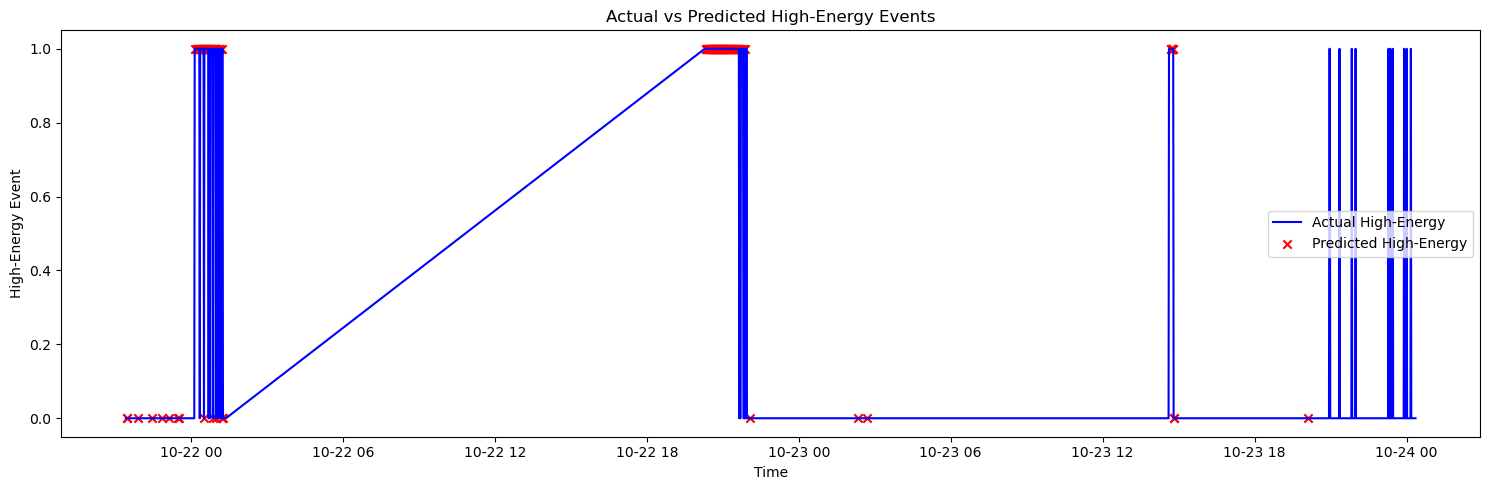

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, precision_recall_curve
)
import lightgbm as lgb
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# ============================================================
# 1️⃣ Load and preprocess dataset
# ============================================================
df = pd.read_excel(
    'D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx'
)
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Handle missing or gap flags
df['energy_increment_fixed'] = df['energy_increment_kwh'].copy()
df.loc[df['gap_flag'] == 1, 'energy_increment_fixed'] = 0

# Fill NaNs in lag/rolling features
lag_rolling_cols = [c for c in df.columns if 'lag' in c or 'rolling' in c]
df[lag_rolling_cols] = df[lag_rolling_cols].fillna(0)

# ============================================================
# 2️⃣ Define target and features
# ============================================================
horizon = 5
df['target_future_sum'] = (
    df['energy_increment_fixed']
    .rolling(window=horizon)
    .sum()
    .shift(-horizon)
)
df = df.dropna(subset=['target_future_sum'])

selected_features = [
    'power','current','voltage','power_factor','apparent_power','pf_efficiency',
    'power_lag1','power_lag2','power_lag3','power_lag5','power_lag10',
    'energy_increment_kwh_lag1','energy_increment_kwh_lag2','energy_increment_kwh_lag3',
    'energy_increment_kwh_lag5','energy_increment_kwh_lag10',
    'power_rolling_mean_3','power_rolling_std_3','power_rolling_mean_5','power_rolling_std_5',
    'power_rolling_mean_10','power_rolling_std_10',
    'energy_increment_kwh_rolling_mean_3','energy_increment_kwh_rolling_std_3',
    'energy_increment_kwh_rolling_mean_5','energy_increment_kwh_rolling_std_5',
    'energy_increment_kwh_rolling_mean_10','energy_increment_kwh_rolling_std_10',
    'hour_sin','hour_cos','day_of_week_sin','day_of_week_cos','is_weekend',
    'time_diff_min','gap_flag','delta_power','delta_voltage','delta_energy'
]

X = df[selected_features].fillna(0)
y_reg = df['target_future_sum']

# ============================================================
# 3️⃣ Split train/test (time-based)
# ============================================================
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_reg, y_test_reg = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

# ============================================================
# 4️⃣ Scale numeric features (after split — no leakage)
# ============================================================
numeric_cols = X.select_dtypes(include=['float64','int64']).columns
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# ============================================================
# 5️⃣ LightGBM Regression (with early stopping)
# ============================================================
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(
    X_train_scaled, y_train_reg,
    eval_set=[(X_test_scaled, y_test_reg)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

y_pred_reg = lgb_model.predict(X_test_scaled)

# Regression evaluation
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)
print(f"LightGBM ΔEnergy Prediction -> MAE:{mae:.6f}, RMSE:{rmse:.6f}, R²:{r2:.6f}")

# ============================================================
# 6️⃣ High-Energy Classification Target
# ============================================================
threshold_energy = df['target_future_sum'].quantile(0.85)
df['high_energy_flag'] = (df['target_future_sum'] > threshold_energy).astype(int)
y_cls = df['high_energy_flag'].iloc[split_idx:].reset_index(drop=True)

# ============================================================
# 7️⃣ Prepare classifier features (include predicted regression)
# ============================================================
X_train_cls = X_train_scaled.copy()
X_test_cls = X_test_scaled.copy()
X_train_cls['predicted_energy'] = lgb_model.predict(X_train_scaled)
X_test_cls['predicted_energy'] = y_pred_reg

# ============================================================
# 8️⃣ Train XGBoost Classifier
# ============================================================
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(
        (len(y_train_reg) - sum(y_train_reg > threshold_energy))
        / sum(y_train_reg > threshold_energy)
    ),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1, verbose=-1
)

xgb_model.fit(X_train_cls, df['high_energy_flag'].iloc[:split_idx])

# Predict probabilities
y_prob = xgb_model.predict_proba(X_test_cls)[:, 1]

# Optimize threshold using F1
precisions, recalls, thresholds = precision_recall_curve(y_cls, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
adjusted_threshold = thresholds[best_idx]
y_pred_cls = (y_prob >= adjusted_threshold).astype(int)

# ============================================================
# 9️⃣ Classification evaluation
# ============================================================
accuracy = accuracy_score(y_cls, y_pred_cls)
precision = precision_score(y_cls, y_pred_cls)
recall = recall_score(y_cls, y_pred_cls)
f1 = f1_score(y_cls, y_pred_cls)
roc_auc = roc_auc_score(y_cls, y_prob)
cm = confusion_matrix(y_cls, y_pred_cls)

print(f"XGBoost High-Energy Classification -> Accuracy:{accuracy:.4f}, "
      f"Precision:{precision:.4f}, Recall:{recall:.4f}, F1:{f1:.4f}, ROC AUC:{roc_auc:.4f}")
print("Confusion Matrix:\n", cm)

# ============================================================
# 🔟 Visualization
# ============================================================
plt.figure(figsize=(15,5))
plt.plot(df['created_at'].iloc[split_idx:], y_cls, label='Actual High-Energy', color='blue')
plt.scatter(
    df['created_at'].iloc[split_idx:][y_pred_cls == 1],
    y_cls[y_pred_cls == 1],
    color='red', label='Predicted High-Energy', marker='x'
)
plt.xlabel('Time')
plt.ylabel('High-Energy Event')
plt.title('Actual vs Predicted High-Energy Events')
plt.legend()
plt.tight_layout()
plt.show()


Dropping highly correlated features: ['current']
Linear Regression (Reduced + Engineered) -> MAE:0.000692, RMSE:0.001335, R²:0.821687
XGBoost High-Energy Classification -> Accuracy:0.9400, Precision:0.8811, Recall:0.7500, F1:0.8103, ROC AUC:0.9518
Confusion Matrix:
 [[799  17]
 [ 42 126]]


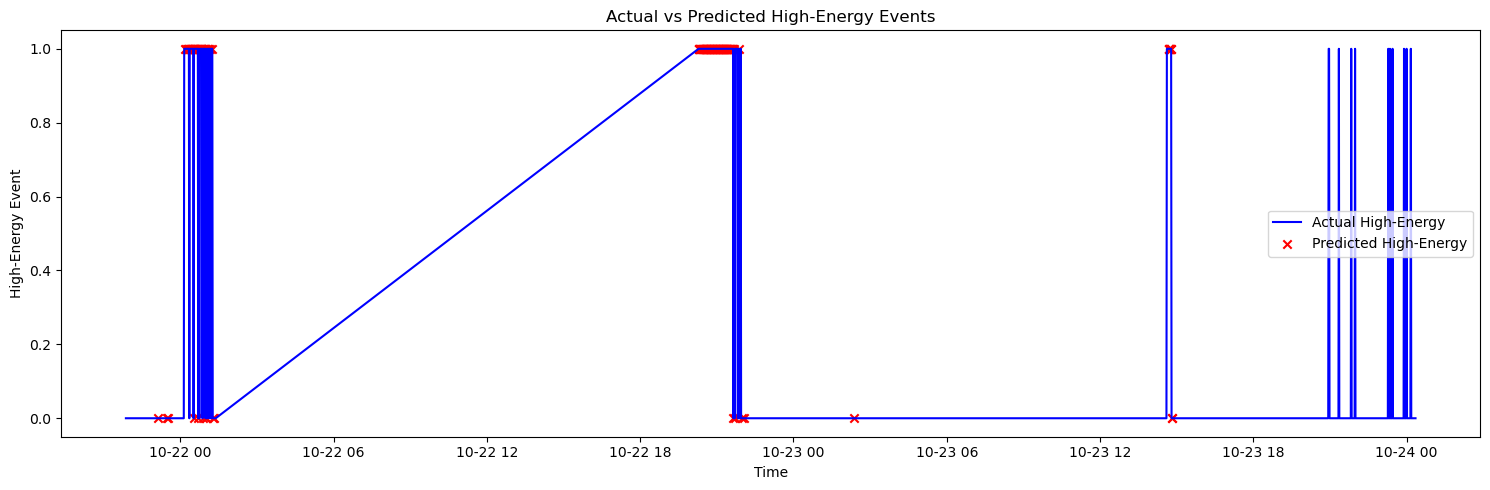

In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, precision_recall_curve
)
from sklearn.linear_model import LinearRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# ============================================================
# Load and preprocess dataset
# ============================================================
df = pd.read_excel(
    'D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx'
)
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Handle missing or gap flags
df['energy_increment_fixed'] = df['energy_increment_kwh'].copy()
df.loc[df['gap_flag'] == 1, 'energy_increment_fixed'] = 0

# ============================================================
# Define target (5-min future energy)
# ============================================================
horizon = 5
df['target_future_sum'] = (
    df['energy_increment_fixed']
    .rolling(window=horizon)
    .sum()
    .shift(-horizon)
)
df = df.dropna(subset=['target_future_sum']).reset_index(drop=True)

# ============================================================
# Add 5-min aligned lag features
# ============================================================
lag_cols = ['energy_increment_fixed','power_factor']
for col in lag_cols:
    df[f'{col}_lag1_5min'] = df[col].shift(horizon)
    df[f'{col}_lag2_5min'] = df[col].shift(horizon*2)

# Drop rows with NaN after lag creation
df = df.dropna().reset_index(drop=True)

# ============================================================
# Select features
# ============================================================
selected_features = [
    'power','current','voltage','power_factor',
    'power_lag5','power_lag10',
    'energy_increment_kwh_lag1','energy_increment_kwh_lag2','energy_increment_kwh_lag3',
    'energy_increment_kwh_lag5','energy_increment_kwh_lag10',
    'power_rolling_std_3','power_rolling_std_5','power_rolling_std_10',
    'energy_increment_kwh_rolling_mean_3','energy_increment_kwh_rolling_std_3',
    'energy_increment_kwh_rolling_mean_5','energy_increment_kwh_rolling_std_5',
    'energy_increment_kwh_rolling_mean_10','energy_increment_kwh_rolling_std_10',
    'hour_sin','hour_cos','day_of_week_sin','day_of_week_cos','is_weekend',
    'time_diff_min','gap_flag','delta_power','delta_voltage','delta_energy'
]

# Include lag features
lag_features = [f'{col}_lag1_5min' for col in lag_cols] + [f'{col}_lag2_5min' for col in lag_cols]
selected_features += lag_features

X = df[selected_features].fillna(0)
y_reg = df['target_future_sum']

# ============================================================
# Feature Engineering
# ============================================================
# Interaction feature
X['power_current'] = X['power'] * X['current']

# ============================================================
# Scale numeric features
# ============================================================
numeric_cols = X.select_dtypes(include=['float64','int64']).columns
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# ============================================================
# Drop highly correlated features
# ============================================================
threshold = 0.9
corr_matrix = X_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
print("Dropping highly correlated features:", to_drop)
X_reduced = X_scaled.drop(columns=to_drop)

# ============================================================
# Train/test split (time-based)
# ============================================================
split_idx = int(len(X_reduced) * 0.8)
X_train_reduced = X_reduced.iloc[:split_idx]
X_test_reduced = X_reduced.iloc[split_idx:]
y_train_reg = y_reg.iloc[:split_idx]
y_test_reg = y_reg.iloc[split_idx:]

# ============================================================
# Linear Regression on reduced + engineered features
# ============================================================
lr_model = LinearRegression()
lr_model.fit(X_train_reduced, y_train_reg)
y_pred_reg = lr_model.predict(X_test_reduced)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Linear Regression (Reduced + Engineered) -> MAE:{mae:.6f}, RMSE:{rmse:.6f}, R²:{r2:.6f}")

# ============================================================
#  High-Energy Classification Target
# ============================================================
threshold_energy = df['target_future_sum'].quantile(0.85)
df['high_energy_flag'] = (df['target_future_sum'] > threshold_energy).astype(int)
y_cls = df['high_energy_flag'].iloc[split_idx:].reset_index(drop=True)

# ============================================================
#  Prepare classifier features (include predicted regression)
# ============================================================
X_train_cls = X_train_reduced.copy()
X_test_cls = X_test_reduced.copy()
X_train_cls['predicted_energy'] = lr_model.predict(X_train_reduced)
X_test_cls['predicted_energy'] = y_pred_reg

# ============================================================
#  Train XGBoost Classifier
# ============================================================
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train_reg) - sum(y_train_reg > threshold_energy)) / sum(y_train_reg > threshold_energy),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1, verbose=-1
)

xgb_model.fit(X_train_cls, df['high_energy_flag'].iloc[:split_idx])

# Predict probabilities
y_prob = xgb_model.predict_proba(X_test_cls)[:, 1]

# Optimize threshold using F1
precisions, recalls, thresholds = precision_recall_curve(y_cls, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
adjusted_threshold = thresholds[best_idx]
y_pred_cls = (y_prob >= adjusted_threshold).astype(int)

# ============================================================
#  Classification evaluation
# ============================================================
accuracy = accuracy_score(y_cls, y_pred_cls)
precision = precision_score(y_cls, y_pred_cls)
recall = recall_score(y_cls, y_pred_cls)
f1 = f1_score(y_cls, y_pred_cls)
roc_auc = roc_auc_score(y_cls, y_prob)
cm = confusion_matrix(y_cls, y_pred_cls)

print(f"XGBoost High-Energy Classification -> Accuracy:{accuracy:.4f}, "
      f"Precision:{precision:.4f}, Recall:{recall:.4f}, F1:{f1:.4f}, ROC AUC:{roc_auc:.4f}")
print("Confusion Matrix:\n", cm)

# ============================================================
#  Visualization
# ============================================================
plt.figure(figsize=(15,5))
plt.plot(df['created_at'].iloc[split_idx:], y_cls, label='Actual High-Energy', color='blue')
plt.scatter(
    df['created_at'].iloc[split_idx:][y_pred_cls == 1],
    y_cls[y_pred_cls == 1],
    color='red', label='Predicted High-Energy', marker='x'
)
plt.xlabel('Time')
plt.ylabel('High-Energy Event')
plt.title('Actual vs Predicted High-Energy Events')
plt.legend()
plt.tight_layout()
plt.show()


In [79]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# ============================================================
# 1. Load dataset
# ============================================================
df = pd.read_excel(
    'D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx'
)

df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Fix gaps
df['energy_increment_fixed'] = df['energy_increment_kwh'].copy()
df.loc[df['gap_flag'] == 1, 'energy_increment_fixed'] = 0

# ============================================================
# 2. Create 5-minute ahead target
# ============================================================
horizon = 5
df['target_future_sum'] = (
    df['energy_increment_fixed']
      .rolling(window=horizon)
      .sum()
      .shift(-horizon)
)

df = df.dropna(subset=['target_future_sum']).reset_index(drop=True)

# ============================================================
# 3. Add 5-min aligned lag features
# ============================================================
lag_cols = ['energy_increment_fixed','power_factor']
for col in lag_cols:
    df[f'{col}_lag1_5min'] = df[col].shift(horizon)
    df[f'{col}_lag2_5min'] = df[col].shift(horizon*2)

df = df.dropna().reset_index(drop=True)

# ============================================================
# 4. SAME FEATURE LIST as your original working model
# ============================================================
selected_features = [
    'power','current','voltage','power_factor',
    'power_lag5','power_lag10',
    'energy_increment_kwh_lag1','energy_increment_kwh_lag2','energy_increment_kwh_lag3',
    'energy_increment_kwh_lag5','energy_increment_kwh_lag10',
    'power_rolling_std_3','power_rolling_std_5','power_rolling_std_10',
    'energy_increment_kwh_rolling_mean_3','energy_increment_kwh_rolling_std_3',
    'energy_increment_kwh_rolling_mean_5','energy_increment_kwh_rolling_std_5',
    'energy_increment_kwh_rolling_mean_10','energy_increment_kwh_rolling_std_10',
    'hour_sin','hour_cos','day_of_week_sin','day_of_week_cos','is_weekend',
    'time_diff_min','gap_flag','delta_power','delta_voltage','delta_energy'
]

# ADD lag1_5min + lag2_5min 
selected_features += [
    'energy_increment_fixed_lag1_5min','energy_increment_fixed_lag2_5min',
    'power_factor_lag1_5min','power_factor_lag2_5min'
]

X = df[selected_features].fillna(0)
y = df['target_future_sum']

# ============================================================
# 5. Feature Engineering — SAME AS ORIGINAL MODEL
# ============================================================
X['power_current'] = X['power'] * X['current']

# ============================================================
# 6. Scale features
# ============================================================
numeric_cols = X.select_dtypes(include=['float64','int64']).columns
scaler = StandardScaler()

X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# ============================================================
# 7. Drop correlated features (same threshold)
# ============================================================
corr_matrix = X_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.90)]

print("Dropped:", to_drop)

X_reduced = X_scaled.drop(columns=to_drop)

# ============================================================
# 8. Train/test split
# ============================================================
split_idx = int(len(X_reduced)*0.8)

X_train = X_reduced.iloc[:split_idx]
X_test  = X_reduced.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

# ============================================================
# 9. Train Linear Regression (original version)
# ============================================================
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n=== FINAL Reproduced Linear Regression ===")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


Dropped: ['current']

=== FINAL Reproduced Linear Regression ===
MAE : 0.0006916437517624728
RMSE: 0.0013354699240954256
R²  : 0.8216867590228677


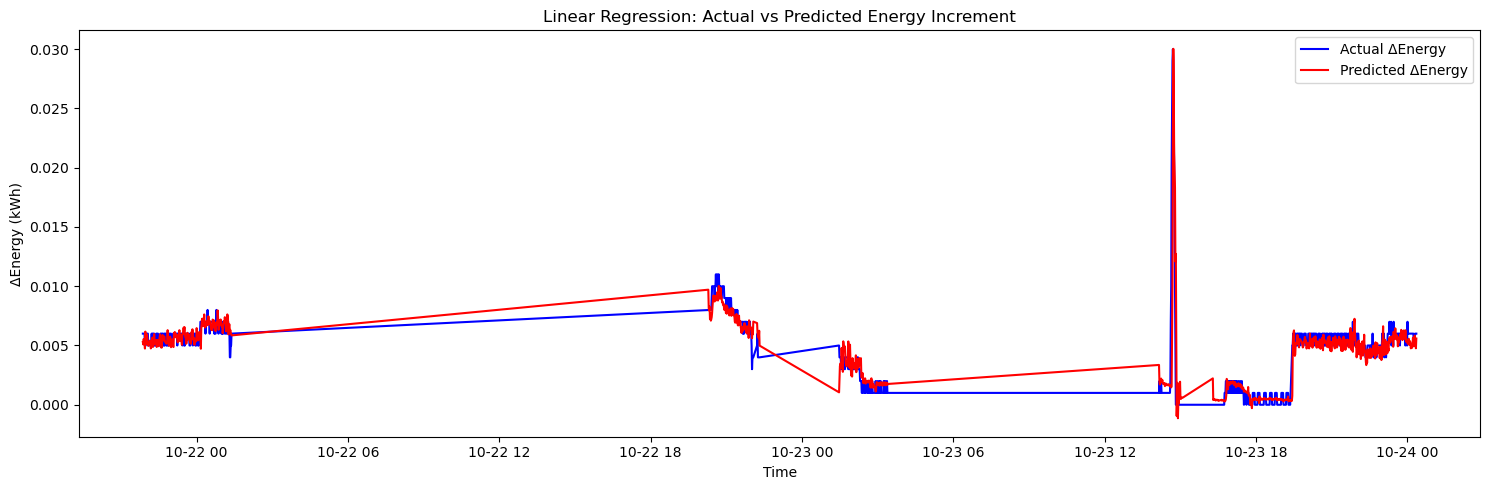

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['created_at'].iloc[split_idx:], y_test.values, label='Actual ΔEnergy', color='blue')
plt.plot(df['created_at'].iloc[split_idx:], y_pred, label='Predicted ΔEnergy', color='red')
plt.xlabel("Time")
plt.ylabel("ΔEnergy (kWh)")
plt.title("Linear Regression: Actual vs Predicted Energy Increment")
plt.legend()
plt.tight_layout()
plt.show()


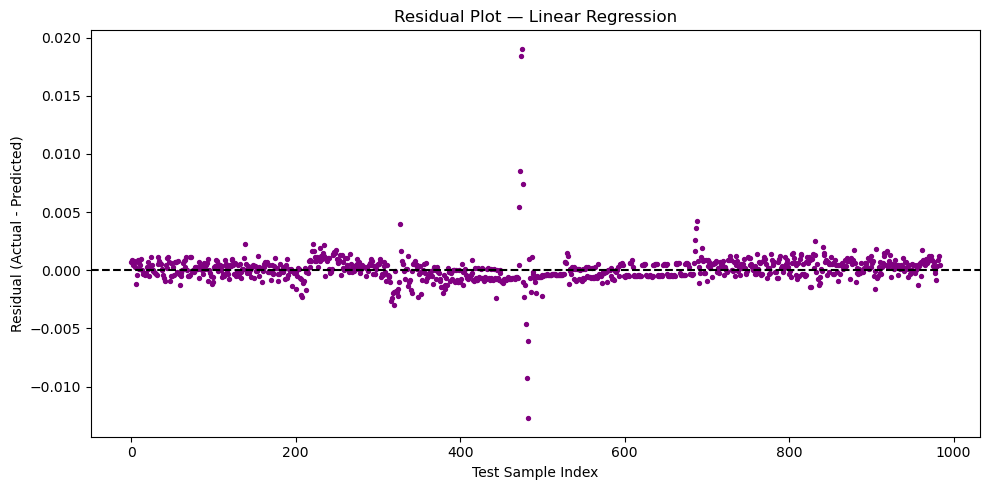

In [81]:
residuals = y_test.values - y_pred

plt.figure(figsize=(10,5))
plt.scatter(range(len(residuals)), residuals, s=8, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Test Sample Index")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot — Linear Regression")
plt.tight_layout()
plt.show()


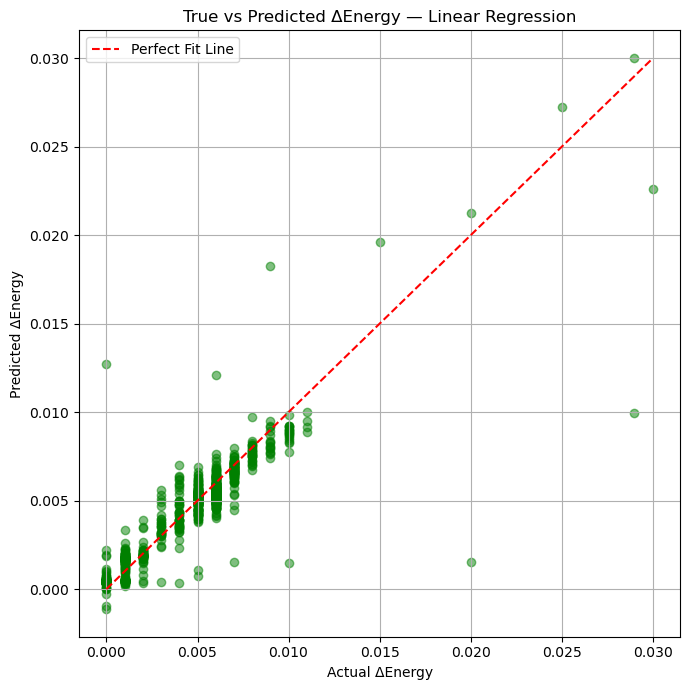

In [82]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Fit Line')
plt.xlabel("Actual ΔEnergy")
plt.ylabel("Predicted ΔEnergy")
plt.title("True vs Predicted ΔEnergy — Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



=== XGBoost High-Energy Classification ===
Accuracy : 0.9380
Precision: 0.8794
Recall   : 0.7381
F1 Score : 0.8026
ROC AUC  : 0.9497
Confusion Matrix:
[[799  17]
 [ 44 124]]


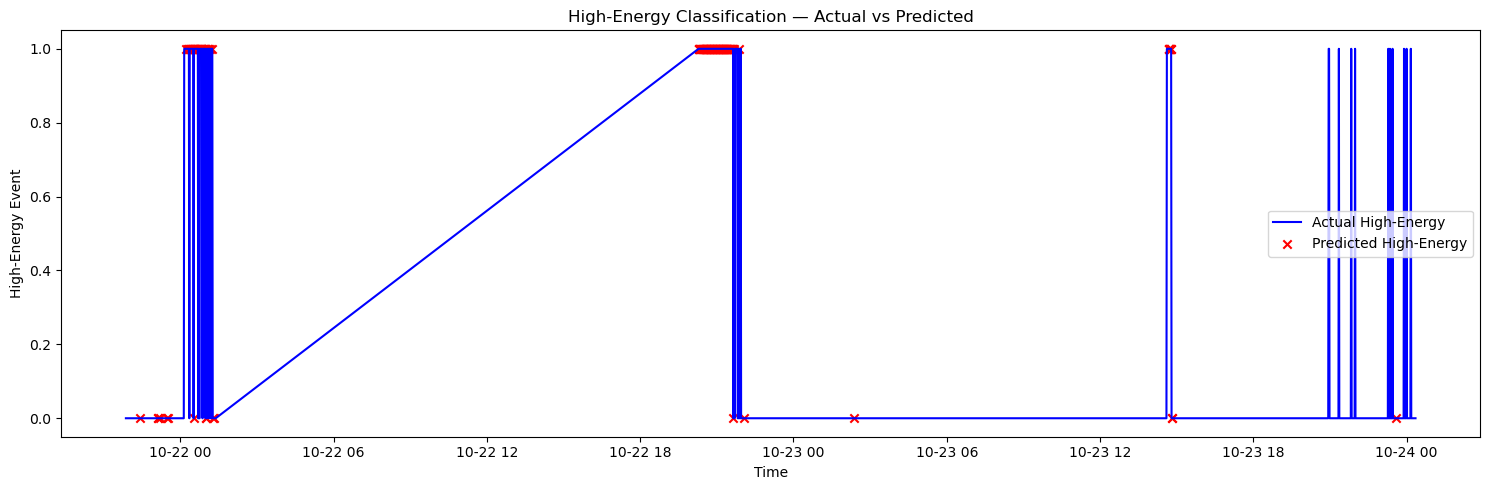

In [74]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, precision_recall_curve
)
from sklearn.linear_model import LinearRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# ============================================================
# 1️⃣ Load and preprocess dataset
# ============================================================
df = pd.read_excel(
    'D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx'
)

df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Handle gaps
df['energy_increment_fixed'] = df['energy_increment_kwh'].copy()
df.loc[df['gap_flag'] == 1, 'energy_increment_fixed'] = 0

# ============================================================
# 2️⃣ Compute 5-min future energy target (for high-energy flag)
# ============================================================
horizon = 5
df['target_future_sum'] = (
    df['energy_increment_fixed']
    .rolling(window=horizon)
    .sum()
    .shift(-horizon)
)
df = df.dropna(subset=['target_future_sum']).reset_index(drop=True)

# ============================================================
# 3️⃣ Create 5-min aligned lag features (needed for LR prediction)
# ============================================================
lag_cols = ['energy_increment_fixed', 'power_factor']
for col in lag_cols:
    df[f'{col}_lag1_5min'] = df[col].shift(horizon)
    df[f'{col}_lag2_5min'] = df[col].shift(horizon * 2)

df = df.dropna().reset_index(drop=True)

# ============================================================
# 4️⃣ Select regression features (for LR prediction)
# ============================================================
selected_features = [
    'power','current','voltage','power_factor',
    'power_lag5','power_lag10',
    'energy_increment_kwh_lag1','energy_increment_kwh_lag2','energy_increment_kwh_lag3',
    'energy_increment_kwh_lag5','energy_increment_kwh_lag10',
    'power_rolling_std_3','power_rolling_std_5','power_rolling_std_10',
    'energy_increment_kwh_rolling_mean_3','energy_increment_kwh_rolling_std_3',
    'energy_increment_kwh_rolling_mean_5','energy_increment_kwh_rolling_std_5',
    'energy_increment_kwh_rolling_mean_10','energy_increment_kwh_rolling_std_10',
    'hour_sin','hour_cos','day_of_week_sin','day_of_week_cos','is_weekend',
    'time_diff_min','gap_flag','delta_power','delta_voltage','delta_energy',
    'energy_increment_fixed_lag1_5min','energy_increment_fixed_lag2_5min',
    'power_factor_lag1_5min','power_factor_lag2_5min'
]

X = df[selected_features].fillna(0)

# Add interaction feature
X['power_current'] = X['power'] * X['current']

# ============================================================
# 5️⃣ Scale features for regression model
# ============================================================
numeric_cols = X.select_dtypes(include=['float64','int64']).columns
scaler = StandardScaler()

X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Correlation removal
corr_matrix = X_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]
X_reduced = X_scaled.drop(columns=to_drop)

# ============================================================
# 6️⃣ Train Linear Regression (used only to generate a predictor feature)
# ============================================================
split_idx = int(len(X_reduced) * 0.8)
X_train_reg = X_reduced.iloc[:split_idx]
X_test_reg = X_reduced.iloc[split_idx:]
y_reg_train = df['target_future_sum'].iloc[:split_idx]
y_reg_test = df['target_future_sum'].iloc[split_idx:]

lr = LinearRegression()
lr.fit(X_train_reg, y_reg_train)

# Regression predictions (used as classifier feature)
train_pred_energy = lr.predict(X_train_reg)
test_pred_energy = lr.predict(X_test_reg)

# ============================================================
# 7️⃣ Create High-Energy Binary Target
# ============================================================
threshold_energy = df['target_future_sum'].quantile(0.85)
df['high_energy_flag'] = (df['target_future_sum'] > threshold_energy).astype(int)

y_cls_train = df['high_energy_flag'].iloc[:split_idx].reset_index(drop=True)
y_cls_test = df['high_energy_flag'].iloc[split_idx:].reset_index(drop=True)

# ============================================================
# 8️⃣ Final Classification Feature Set
# ============================================================
X_train_cls = X_train_reg.copy()
X_test_cls = X_test_reg.copy()

# Add LR predicted energy as feature
X_train_cls['predicted_energy'] = train_pred_energy
X_test_cls['predicted_energy'] = test_pred_energy

# ============================================================
# 9️⃣ Train XGBoost Classifier
# ============================================================
xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(
        (len(y_cls_train) - sum(y_cls_train == 1))
        / sum(y_cls_train == 1)
    ),
    eval_metric='logloss',
    random_state=42
)

xgb_clf.fit(X_train_cls, y_cls_train)

# ============================================================
# 🔟 Predict and Evaluate
# ============================================================
y_prob = xgb_clf.predict_proba(X_test_cls)[:, 1]

# Best threshold based on F1
precisions, recalls, thresholds = precision_recall_curve(y_cls_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

y_pred = (y_prob >= best_threshold).astype(int)

# Metrics
accuracy = accuracy_score(y_cls_test, y_pred)
precision = precision_score(y_cls_test, y_pred)
recall = recall_score(y_cls_test, y_pred)
f1 = f1_score(y_cls_test, y_pred)
roc_auc = roc_auc_score(y_cls_test, y_prob)
cm = confusion_matrix(y_cls_test, y_pred)

print("\n=== XGBoost High-Energy Classification ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print("Confusion Matrix:")
print(cm)

# ============================================================
# 1️⃣1️⃣ Visualization
# ============================================================
plt.figure(figsize=(15,5))
plt.plot(df['created_at'].iloc[split_idx:], y_cls_test, label='Actual High-Energy', color='blue')
plt.scatter(
    df['created_at'].iloc[split_idx:][y_pred == 1],
    y_cls_test[y_pred == 1],
    color='red', label='Predicted High-Energy', marker='x'
)
plt.xlabel('Time')
plt.ylabel('High-Energy Event')
plt.title('High-Energy Classification — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()


In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

# ============================================================
# 1️⃣ Train Logistic Regression Classifier
# ============================================================
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',   # handle class imbalance
    solver='lbfgs'             # stable general solver
)

log_reg.fit(X_train_cls, y_cls_train)

# ============================================================
# 2️⃣ Predict probabilities & optimize threshold
# ============================================================
y_prob_log = log_reg.predict_proba(X_test_cls)[:, 1]

# Same F1-based threshold optimization
precisions, recalls, thresholds = precision_recall_curve(y_cls_test, y_prob_log)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold_log = thresholds[best_idx]

y_pred_log = (y_prob_log >= best_threshold_log).astype(int)

# ============================================================
# 3️⃣ Evaluation
# ============================================================
acc_log = accuracy_score(y_cls_test, y_pred_log)
prec_log = precision_score(y_cls_test, y_pred_log)
recall_log = recall_score(y_cls_test, y_pred_log)
f1_log = f1_score(y_cls_test, y_pred_log)
roc_log = roc_auc_score(y_cls_test, y_prob_log)
cm_log = confusion_matrix(y_cls_test, y_pred_log)

print("\n=== Logistic Regression Classifier ===")
print(f"Accuracy : {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall   : {recall_log:.4f}")
print(f"F1 Score : {f1_log:.4f}")
print(f"ROC AUC  : {roc_log:.4f}")
print("Confusion Matrix:")
print(cm_log)



=== Logistic Regression Classifier ===
Accuracy : 0.9451
Precision: 0.8239
Recall   : 0.8631
F1 Score : 0.8430
ROC AUC  : 0.9523
Confusion Matrix:
[[785  31]
 [ 23 145]]


In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, precision_recall_curve
)

# ============================================================
# 1️⃣ Train Random Forest Classifier
# ============================================================
rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_cls, y_cls_train)

# ============================================================
# 2️⃣ Predict probabilities & optimize threshold (same method)
# ============================================================
y_prob_rf = rf_clf.predict_proba(X_test_cls)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_cls_test, y_prob_rf)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold_rf = thresholds[best_idx]

y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)

# ============================================================
# 3️⃣ Evaluation
# ============================================================
acc_rf = accuracy_score(y_cls_test, y_pred_rf)
prec_rf = precision_score(y_cls_test, y_pred_rf)
recall_rf = recall_score(y_cls_test, y_pred_rf)
f1_rf = f1_score(y_cls_test, y_pred_rf)
roc_rf = roc_auc_score(y_cls_test, y_prob_rf)
cm_rf = confusion_matrix(y_cls_test, y_pred_rf)

print("\n=== Random Forest Classifier ===")
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC AUC  : {roc_rf:.4f}")
print("Confusion Matrix:")
print(cm_rf)



=== Random Forest Classifier ===
Accuracy : 0.9522
Precision: 0.8712
Recall   : 0.8452
F1 Score : 0.8580
ROC AUC  : 0.9618
Confusion Matrix:
[[795  21]
 [ 26 142]]


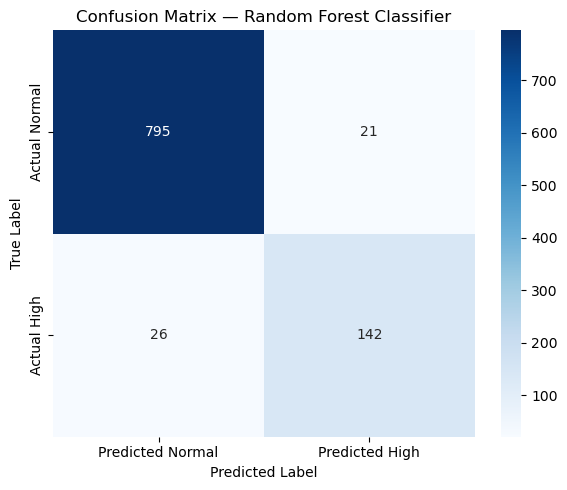

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal','Predicted High'],
            yticklabels=['Actual Normal','Actual High'])

plt.title("Confusion Matrix — Random Forest Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


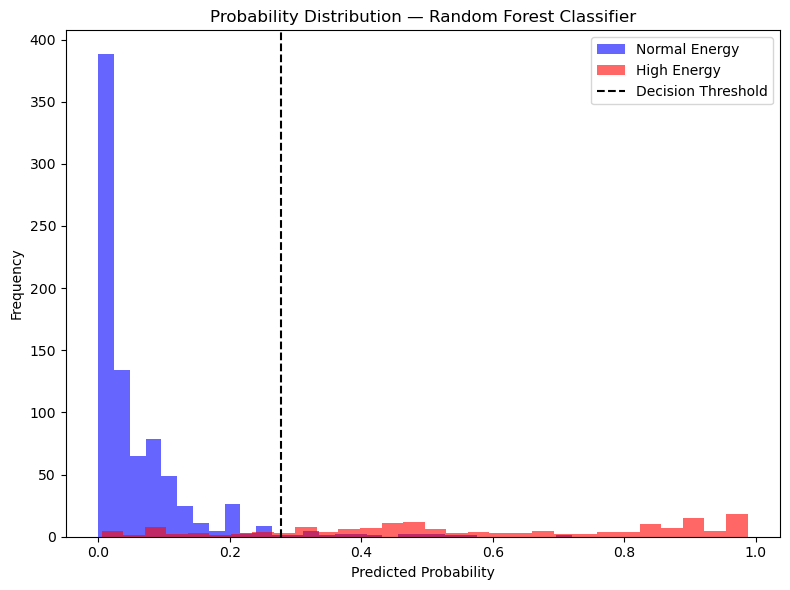

In [85]:
plt.figure(figsize=(8,6))

plt.hist(y_prob_rf[y_cls_test==0], bins=30, alpha=0.6, label="Normal Energy", color='blue')
plt.hist(y_prob_rf[y_cls_test==1], bins=30, alpha=0.6, label="High Energy", color='red')

plt.axvline(best_threshold_rf, color='black', linestyle='--', label='Decision Threshold')

plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Probability Distribution — Random Forest Classifier")
plt.legend()
plt.tight_layout()
plt.show()


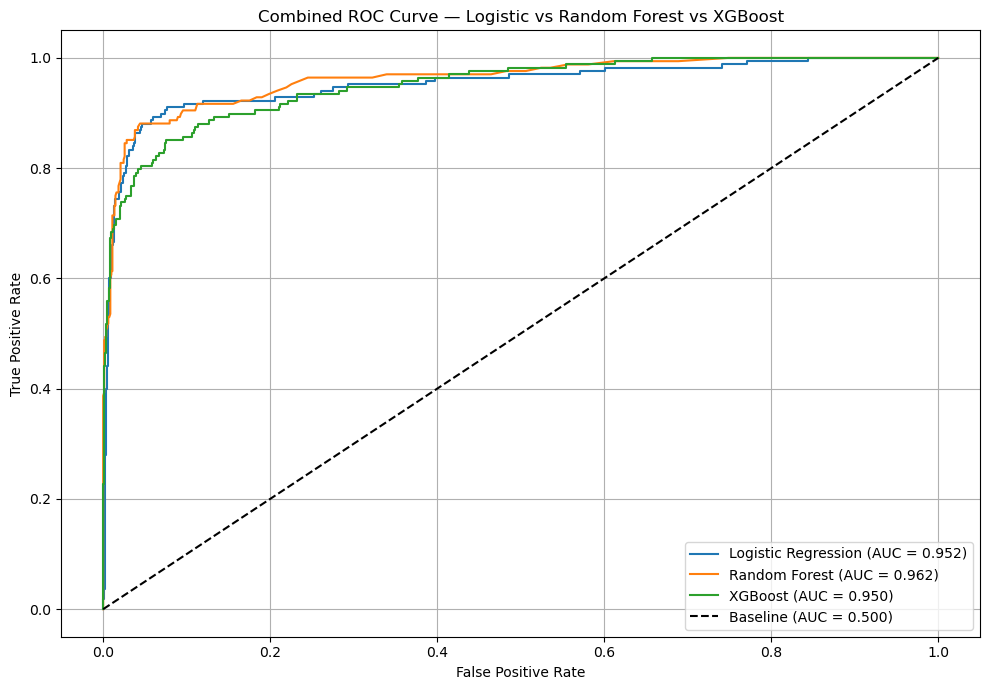

In [77]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ============================================================
# Compute ROC curve points
# ============================================================

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_cls_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_cls_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_cls_test, y_prob)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# ============================================================
# Plot all ROC curves together
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')

# Baseline (random guessing)
plt.plot([0, 1], [0, 1], 'k--', label='Baseline (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curve — Logistic vs Random Forest vs XGBoost')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


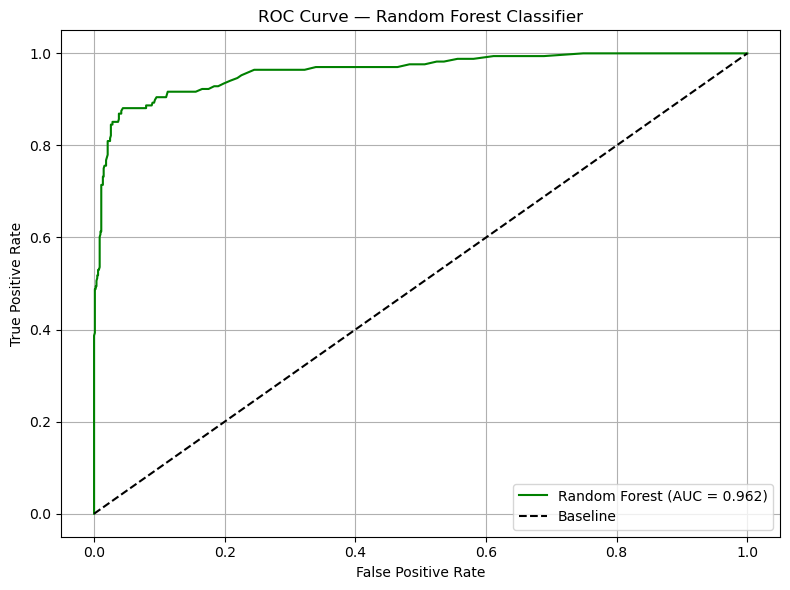

In [78]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_cls_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest Classifier')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [67]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, precision_recall_curve
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# ============================================================
# Load and preprocess dataset
# ============================================================
df = pd.read_excel(
    'D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx'
)
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Handle missing or gap flags
df['energy_increment_fixed'] = df['energy_increment_kwh'].copy()
df.loc[df['gap_flag'] == 1, 'energy_increment_fixed'] = 0

# ============================================================
# Define target (5-min future energy)
# ============================================================
horizon = 5
df['target_future_sum'] = (
    df['energy_increment_fixed']
    .rolling(window=horizon)
    .sum()
    .shift(-horizon)
)
df = df.dropna(subset=['target_future_sum']).reset_index(drop=True)

# ============================================================
# Add 5-min aligned lag features
# ============================================================
lag_cols = ['energy_increment_fixed','power_factor']
for col in lag_cols:
    df[f'{col}_lag1_5min'] = df[col].shift(horizon)
    df[f'{col}_lag2_5min'] = df[col].shift(horizon*2)

df = df.dropna().reset_index(drop=True)

# Interaction feature
df['power_current'] = df['power'] * df['current']

# ============================================================
# Select regression features
# ============================================================
selected_features = [
    'power','voltage','power_factor',
    'power_lag5','power_lag10',
    'energy_increment_kwh_lag1','energy_increment_kwh_lag2','energy_increment_kwh_lag3',
    'energy_increment_kwh_lag5','energy_increment_kwh_lag10',
    'power_rolling_std_3','power_rolling_std_5','power_rolling_std_10',
    'energy_increment_kwh_rolling_mean_3','energy_increment_kwh_rolling_std_3',
    'energy_increment_kwh_rolling_mean_5','energy_increment_kwh_rolling_std_5',
    'energy_increment_kwh_rolling_mean_10','energy_increment_kwh_rolling_std_10',
    'hour_sin','hour_cos','day_of_week_sin','day_of_week_cos','is_weekend',
    'time_diff_min','gap_flag','delta_power','delta_voltage','delta_energy',
    'energy_increment_fixed_lag1_5min','energy_increment_fixed_lag2_5min',
    'power_factor_lag1_5min','power_factor_lag2_5min','power_current'
]

X = df[selected_features].fillna(0)
y_reg = df['target_future_sum']

# ============================================================
# Scale features (NO feature dropping)
# ============================================================
numeric_cols = X.select_dtypes(include=['float64','int64']).columns
scaler = StandardScaler()

X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Keep ALL features (no reduction)
X_final = X_scaled.copy()
print("Using all features — none dropped")

# ============================================================
# Time-based split
# ============================================================
split_idx = int(len(X_final)*0.8)

X_train = X_final.iloc[:split_idx]
X_test  = X_final.iloc[split_idx:]
y_train_reg = y_reg.iloc[:split_idx]
y_test_reg  = y_reg.iloc[split_idx:]

# ============================================================
# Linear Regression (for predicted energy)
# ============================================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_reg)

y_pred_reg = lr_model.predict(X_test)

print("\n=== Linear Regression Results ===")
print(f"MAE : {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.4f}")
print(f"R²  : {r2_score(y_test_reg, y_pred_reg):.4f}")

# ============================================================
# High-energy classification target
# ============================================================
threshold_energy = df['target_future_sum'].quantile(0.85)
df['high_energy_flag'] = (df['target_future_sum'] > threshold_energy).astype(int)

y_cls_train = df['high_energy_flag'].iloc[:split_idx].reset_index(drop=True)
y_cls_test  = df['high_energy_flag'].iloc[split_idx:].reset_index(drop=True)

# Build classification features
X_train_cls = X_train.copy()
X_test_cls  = X_test.copy()

# Add predicted energy
X_train_cls['predicted_energy'] = lr_model.predict(X_train)
X_test_cls['predicted_energy']  = y_pred_reg

# ============================================================
# Random Forest Classifier
# ============================================================
rf_clf = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_cls, y_cls_train)

# Predict
y_prob_rf = rf_clf.predict_proba(X_test_cls)[:, 1]

# Best threshold using F1
precisions, recalls, thresholds = precision_recall_curve(y_cls_test, y_prob_rf)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

y_pred_rf = (y_prob_rf >= best_thresh).astype(int)

# ============================================================
# Evaluation
# ============================================================
print("\n=== Random Forest Classification ===")
print(f"Accuracy : {accuracy_score(y_cls_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_cls_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_cls_test, y_pred_rf):.4f}")
print(f"F1 Score : {f1_score(y_cls_test, y_pred_rf):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_cls_test, y_prob_rf):.4f}")



Using all features — none dropped

=== Linear Regression Results ===
MAE : 0.0007
RMSE: 0.0013
R²  : 0.8217

=== Random Forest Classification ===
Accuracy : 0.9522
Precision: 0.8712
Recall   : 0.8452
F1 Score : 0.8580
ROC AUC  : 0.9618


In [68]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, precision_recall_curve
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import os

# Create folders if not exist
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# ============================================================
# 1️⃣ Load and preprocess dataset
# ============================================================
df = pd.read_excel(
    'D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx'
)
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Fix missing increments using gap flag
df['energy_increment_fixed'] = df['energy_increment_kwh'].copy()
df.loc[df['gap_flag'] == 1, 'energy_increment_fixed'] = 0

# Interaction feature
df['power_current'] = df['power'] * df['current']

# ============================================================
# 2️⃣ Create 5-minute future energy target
# ============================================================
horizon = 5
df['target_future_sum'] = (
    df['energy_increment_fixed']
    .rolling(window=horizon)
    .sum()
    .shift(-horizon)
)

df = df.dropna(subset=['target_future_sum']).reset_index(drop=True)

# ============================================================
# 3️⃣ Add 5-min aligned lags
# ============================================================
lag_cols = ['energy_increment_fixed','power_factor']
for col in lag_cols:
    df[f'{col}_lag1_5min'] = df[col].shift(horizon)
    df[f'{col}_lag2_5min'] = df[col].shift(horizon*2)

df = df.dropna().reset_index(drop=True)

# ============================================================
# 4️⃣ Select Features
# ============================================================
selected_features = [
    'power','voltage','power_factor','power_current',
    'power_lag5','power_lag10',
    'energy_increment_kwh_lag1','energy_increment_kwh_lag2','energy_increment_kwh_lag3',
    'energy_increment_kwh_lag5','energy_increment_kwh_lag10',
    'power_rolling_std_3','power_rolling_std_5','power_rolling_std_10',
    'energy_increment_kwh_rolling_mean_3','energy_increment_kwh_rolling_std_3',
    'energy_increment_kwh_rolling_mean_5','energy_increment_kwh_rolling_std_5',
    'energy_increment_kwh_rolling_mean_10','energy_increment_kwh_rolling_std_10',
    'hour_sin','hour_cos','day_of_week_sin','day_of_week_cos',
    'is_weekend','time_diff_min','gap_flag',
    'delta_power','delta_voltage','delta_energy',
    'energy_increment_fixed_lag1_5min','energy_increment_fixed_lag2_5min',
    'power_factor_lag1_5min','power_factor_lag2_5min'
]

X = df[selected_features].fillna(0)
y_reg = df['target_future_sum']

# ============================================================
# 5️⃣ Scale Features (NO CORRELATION DROPPING)
# ============================================================
numeric_cols = X.select_dtypes(include=['float64','int64']).columns
scaler = StandardScaler()

X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X_final = X_scaled.copy()
print("Using all features — none dropped")

# ============================================================
# 6️⃣ Time-based Split
# ============================================================
split_idx = int(len(X_final) * 0.80)
X_train = X_final.iloc[:split_idx]
X_test = X_final.iloc[split_idx:]

y_train_reg = y_reg.iloc[:split_idx]
y_test_reg = y_reg.iloc[split_idx:]

# ============================================================
# 7️⃣ Linear Regression (Regression Model)
# ============================================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_reg)

y_pred_reg = lr_model.predict(X_test)

print("\n=== Linear Regression Results ===")
print(f"MAE  : {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.4f}")
print(f"R²   : {r2_score(y_test_reg, y_pred_reg):.4f}")

# ============================================================
# 8️⃣ Classification: High Energy Event
# ============================================================
threshold_energy = df['target_future_sum'].quantile(0.85)
df['high_energy_flag'] = (df['target_future_sum'] > threshold_energy).astype(int)

y_cls_train = df['high_energy_flag'].iloc[:split_idx].reset_index(drop=True)
y_cls_test = df['high_energy_flag'].iloc[split_idx:].reset_index(drop=True)

# Add LR predicted energy as feature
X_train_cls = X_train.copy()
X_test_cls = X_test.copy()

X_train_cls['predicted_energy'] = lr_model.predict(X_train)
X_test_cls['predicted_energy'] = y_pred_reg

# ============================================================
# 9️⃣ Random Forest Classifier (Replaces XGBoost)
# ============================================================
rf_clf = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_cls, y_cls_train)

# Predict probabilities
y_prob_rf = rf_clf.predict_proba(X_test_cls)[:, 1]

# Best threshold based on F1
precisions, recalls, thresholds = precision_recall_curve(y_cls_test, y_prob_rf)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

y_pred_rf = (y_prob_rf >= best_thresh).astype(int)

# ============================================================
# 🔟 Classification Evaluation
# ============================================================
print("\n=== Random Forest High-Energy Classification ===")
print(f"Accuracy : {accuracy_score(y_cls_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_cls_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_cls_test, y_pred_rf):.4f}")
print(f"F1 Score : {f1_score(y_cls_test, y_pred_rf):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_cls_test, y_prob_rf):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_cls_test, y_pred_rf))

# ============================================================
# 🔥 Save Models for SmartTenaga Dashboard
# ============================================================
# feature_names = X_train_cls.columns.tolist()
# with open("models/feature_names.pkl", "wb") as f:
#     pickle.dump(feature_names, f)

# with open("models/lr_model_st.pkl", "wb") as f:
#     pickle.dump(lr_model, f)

# with open("models/rf_model_st.pkl", "wb") as f:  # updated from xgboost
#     pickle.dump(rf_clf, f)

# with open("models/scaler_st.pkl", "wb") as f:
#     pickle.dump(scaler, f)

# print("\nModels and scaler saved successfully!")


Using all features — none dropped

=== Linear Regression Results ===
MAE  : 0.0007
RMSE : 0.0013
R²   : 0.8217

=== Random Forest High-Energy Classification ===
Accuracy : 0.9512
Precision: 0.8659
Recall   : 0.8452
F1 Score : 0.8554
ROC AUC  : 0.9614
Confusion Matrix:
[[794  22]
 [ 26 142]]
